#  E-Commerce Sales & Customer Intelligence 🛍️

<div style="background-color: #6590af; padding: 15px; border-radius: 8px;">
    <b style="color: #112c3f; font-size: 16px;">Table of Contents</b>
    <ol style="color: #1d2931; margin-top: 10px;">
        <li>Data Loading & Initial Inspection</li>
        <li>Data Understanding</li>
        <li>Data Cleaning</li>
        <li>Feature Engineering</li>
        <li>Analysis & Visualization</li>
    </ol>
</div>

## 1. Data Loading & Initial Ispection

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

print('everything is ready 🎉🎉')
print(f'openpyx1 version: {openpyxl.__version__}')


everything is ready 🎉🎉
openpyx1 version: 3.1.5


In [99]:
file_path=r"C:\Users\khali\OneDrive\سطح المكتب\12 Mounths Python Projects\September Project\data\Online Retail.xlsx"
df_Ret=pd.read_excel(file_path)

In [100]:
df_Ret.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Understanding

In [101]:
df_Ret.shape

(541909, 8)

In [102]:
df_Ret.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [103]:
df_Ret.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [104]:
df_Ret.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [105]:
df_Ret.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [106]:
df_Ret.describe(include=['object','str'])

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [107]:
df_Ret.sample(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
391816,570680,23527,WALL ART ANIMALS AND NATURE,4,2011-10-11 15:36:00,3.75,13969.0,United Kingdom
414783,572484,21975,PACK OF 60 DINOSAUR CAKE CASES,2,2011-10-24 13:50:00,0.55,17220.0,United Kingdom
484877,577544,22540,MINI JIGSAW CIRCUS PARADE,4,2011-11-20 14:43:00,0.42,17758.0,United Kingdom
69263,541969,84913B,MINT GREEN ROSE TOWEL,2,2011-01-24 13:46:00,3.29,NaN,United Kingdom
501822,578833,20963,APPLE BATH SPONGE,2,2011-11-25 15:23:00,2.46,NaN,United Kingdom
190586,553199,21932,SCANDINAVIAN PAISLEY PICNIC BAG,5,2011-05-15 15:14:00,1.65,17758.0,United Kingdom
102336,545014,22720,SET OF 3 CAKE TINS PANTRY DESIGN,6,2011-02-25 13:15:00,4.95,18223.0,United Kingdom
520981,580306,20971,PINK BLUE FELT CRAFT TRINKET BOX,12,2011-12-02 14:29:00,1.25,14250.0,United Kingdom
21245,538071,84707B,PINK JEWELLED MIRROR TRINKET TRAY,1,2010-12-09 14:09:00,8.47,NaN,United Kingdom
502190,578844,20979,36 PENCILS TUBE RED RETROSPOT,1,2011-11-25 16:14:00,2.46,NaN,United Kingdom


## 3. Data Cleaning

In [108]:
df_clean= df_Ret.copy()

In [109]:
df_clean= df_Ret.dropna(subset=['Description'])

In [110]:
df_clean= df_clean[df_clean['Quantity'] > 0]
# Negative quantities represent returns made by customers.Since this analysis focuses on actual purchasing bahavior,we have excluded them for now.

In [111]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]
# It is unreasonable for a product price to be zero or negative (except in very rare cases,such as free samples, which could distort the analysis).

In [112]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

In [113]:
df_clean = df_clean.drop_duplicates()

In [114]:
df_clean['TotalSales']= df_clean['Quantity'] * df_clean['UnitPrice']

In [115]:
df_clean.shape

(524878, 9)

## 4. Feature Engineering

In [116]:
df_sales=df_clean.copy()

print(f'New DataFrame name : df_sales')
print(f'Shape : {df_sales.shape}')

New DataFrame name : df_sales
Shape : (524878, 9)


In [117]:
#Date-Based Features

df_sales['Month']= df_sales['InvoiceDate'].dt.month

In [118]:
df_sales['DayOfWeek']= df_sales['InvoiceDate'].dt.dayofweek

In [119]:
df_sales['Hour']= df_sales['InvoiceDate'].dt.hour

In [120]:
df_sales['Quarter'] = df_sales['InvoiceDate'].dt.quarter

In [121]:
df_sales['IsWeekend']= df_sales['DayOfWeek'].isin([5,6]).astype(int)

In [122]:
print("New columns:", ['Month' ,'DayOfWeek','Hour','Quarter','IsWeekend'])
print(f'Shape after date features:{df_sales.shape}')


New columns: ['Month', 'DayOfWeek', 'Hour', 'Quarter', 'IsWeekend']
Shape after date features:(524878, 14)


In [123]:
df_sales[['Month' ,'DayOfWeek','Hour','Quarter','IsWeekend']].head()

,Month,DayOfWeek,Hour,Quarter,IsWeekend
0,12,2,8,4,0
1,12,2,8,4,0
2,12,2,8,4,0
3,12,2,8,4,0
4,12,2,8,4,0


In [124]:
# Customer-Based Features
Customer_features = df_sales.groupby('CustomerID').agg({'InvoiceDate':['min','max','count'],'TotalSales':'sum'}).reset_index()

In [125]:
Customer_features.columns=['CustomerID','FirstPurchase','LastPurchase','NumOrders','TotalSpent']

In [126]:
Customer_features['LoyalityDays']=(Customer_features['LastPurchase']- Customer_features['FirstPurchase']).dt.days

In [127]:
Customer_features['AvgOrderValue']=(Customer_features['TotalSpent'] / Customer_features['NumOrders'])

In [128]:
print(f'Total Customers :{Customer_features.shape[0]:,}')
print(f'Customer features shape :{Customer_features.shape}')

Customer_features.head()

Total Customers :4,338
Customer features shape :(4338, 7)


,CustomerID,FirstPurchase,LastPurchase,NumOrders,TotalSpent,LoyalityDays,AvgOrderValue
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,0,77183.600000
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,182,4310.00,365,23.681319
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,31,1797.24,282,57.975484
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,73,1757.55,0,24.076027
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,17,334.40,0,19.670588


In [129]:
# Classify Customers
def clssify_customer(spent):
    if spent >= 10000:
        return 'Gold'
    elif spent >= 3000:
        return 'Silver'
    else:
        return 'Bronze'
    
Customer_features['Segment']= Customer_features['TotalSpent'].apply(clssify_customer)


In [130]:
print('\n Customer Segments Distribution:')
print(Customer_features['Segment'].value_counts())
print('\n Segment Percentages:')
print(Customer_features['Segment'].value_counts(normalize=True)*100)


 Customer Segments Distribution:
Segment
Bronze    3784
Silver     450
Gold       104
Name: count, dtype: int64

 Segment Percentages:
Segment
Bronze    87.229138
Silver    10.373444
Gold       2.397418
Name: proportion, dtype: float64


In [131]:
print(Customer_features.shape)
Customer_features.head()

(4338, 8)


,CustomerID,FirstPurchase,LastPurchase,NumOrders,TotalSpent,LoyalityDays,AvgOrderValue,Segment
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,0,77183.600000,Gold
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,182,4310.00,365,23.681319,Silver
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,31,1797.24,282,57.975484,Bronze
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,73,1757.55,0,24.076027,Bronze
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,17,334.40,0,19.670588,Bronze


In [132]:
print('='*50)
print(f' Final shape after feature engineering: {df_sales.shape}')
print('='*50)

df_sales.head()
      

 Final shape after feature engineering: (524878, 14)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month,DayOfWeek,Hour,Quarter,IsWeekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2,8,4,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,4,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2,8,4,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,4,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,4,0


In [133]:
# Save Customer Features to CSV for future use and reproducibility
import os

output_path = '../data/customer_features.csv'
Customer_features.to_csv(output_path, index=False)

print(f"✅ File saved successfully at: {output_path}")

✅ File saved successfully at: ../data/customer_features.csv


## 5. Analysis & Visualization

In [134]:
# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")  
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

### 5.1 Sales Analysis

##### 5.1.1 Top Products by Quantity

In [135]:
top_products = df_sales.groupby('Description')['Quantity'].sum().nlargest(10)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [136]:
print(len(top_products))

10


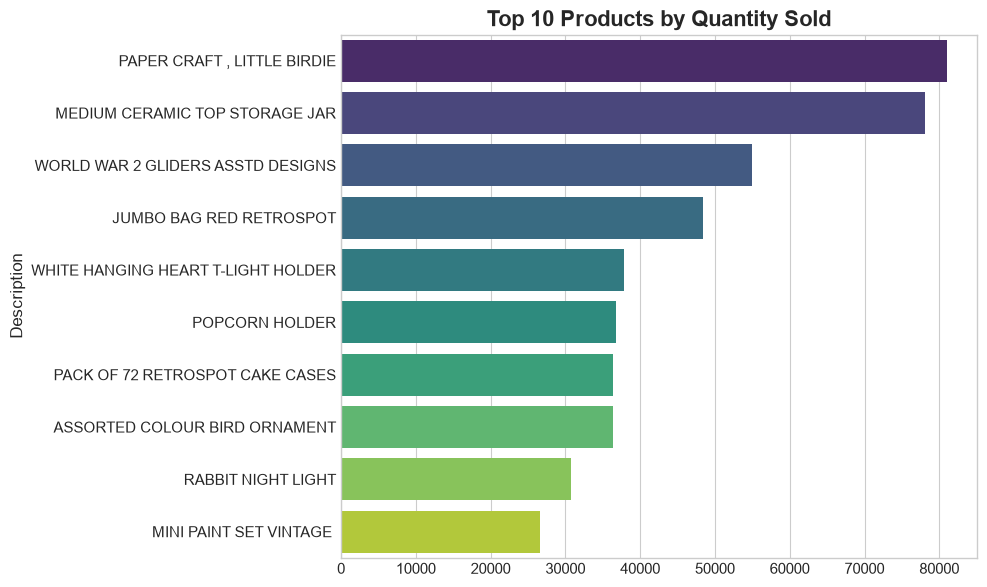

In [137]:
sns.barplot(x=top_products.values,y=top_products.index,hue=top_products.index,palette='viridis',legend= False)

plt.title('Top 10 Products by Quantity Sold')

plt.tight_layout()

plt.show()


##### 5.1.2 Top 10 Products by Revenue

##### 5.1.2.1 Initial Top 10 Products by Revenue (Before Cleaning)

The initial analysis revealed non-product entries in the top 10.

In [138]:
# The Top 10 Products by Revenue list included administrative entries that are not actual produts 

top_products_revenue = df_sales.groupby('Description')['TotalSales'].sum().nlargest(10)
top_products_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalSales, dtype: float64

##### 5.1.2.2 Top 10 Products by Revenue (After Excluding Non-Products)

In [139]:
non_products = ['DOTCOM POSTAGE', 'POSTAGE', 'Manual', 'BANK CHARGES',
                'AMAZON FEE', 'CRUK Commission', 'Discount', 'Adjust bad debt',
                'SAMPLES', 'Found', 'TEST001', 'TEST002']

df_sales_products= df_sales[~df_sales['Description'].isin(non_products)]

print(f"Shape before excluding non-products: {df_sales.shape}")
print(f"Shape after excluding non-products: {df_sales_products.shape}")
print(f"Rows removed: {df_sales.shape[0] - df_sales_products.shape[0]}")

top_products_revenue_filtered = df_sales_products.groupby('Description')['TotalSales'].sum().nlargest(10)
top_products_revenue_filtered.head(10)

Shape before excluding non-products: (524878, 14)
Shape after excluding non-products: (522724, 14)
Rows removed: 2154


Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: TotalSales, dtype: float64

In [140]:
print(len(top_products_revenue_filtered))

10


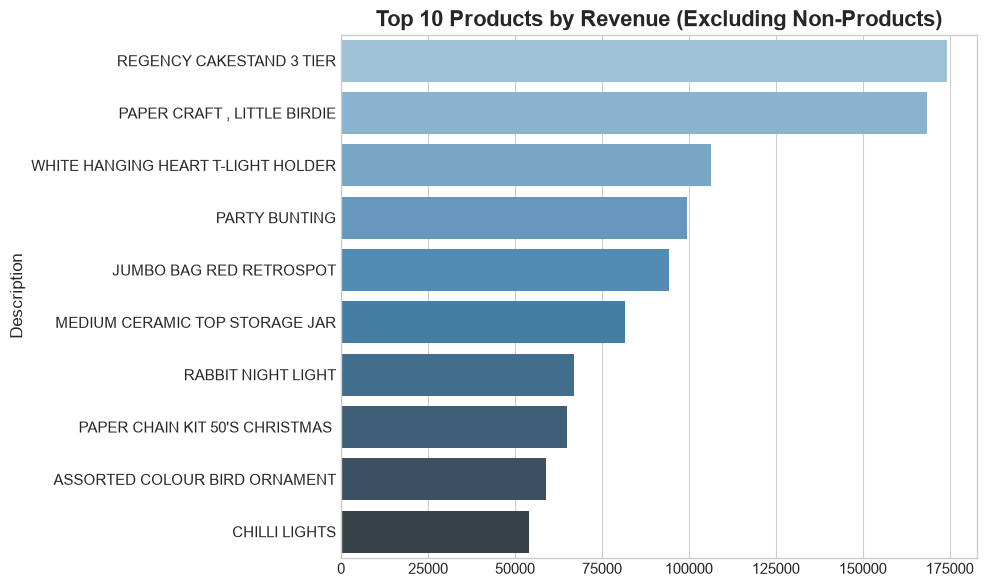

In [141]:
colors = sns.color_palette("Blues_d", n_colors=10)

sns.barplot(x=top_products_revenue_filtered.values, y=top_products_revenue_filtered.index,hue=top_products_revenue.index, palette=colors,legend= False)

plt.title('Top 10 Products by Revenue (Excluding Non-Products)')

plt.tight_layout()

plt.show()

### 5.1.3 Top Customers

In [142]:
top_customers= Customer_features.nlargest(10,'TotalSpent')[['CustomerID','TotalSpent','NumOrders','Segment']]
top_customers.head(10)

,CustomerID,TotalSpent,NumOrders,Segment
1689,14646.0,280206.02,2076,Gold
4201,18102.0,259657.30,431,Gold
3728,17450.0,194390.79,336,Gold
3008,16446.0,168472.50,3,Gold
1879,14911.0,143711.17,5670,Gold
55,12415.0,124914.53,714,Gold
1333,14156.0,117210.08,1395,Gold
3771,17511.0,91062.38,963,Gold
2702,16029.0,80850.84,241,Gold
0,12346.0,77183.60,1,Gold


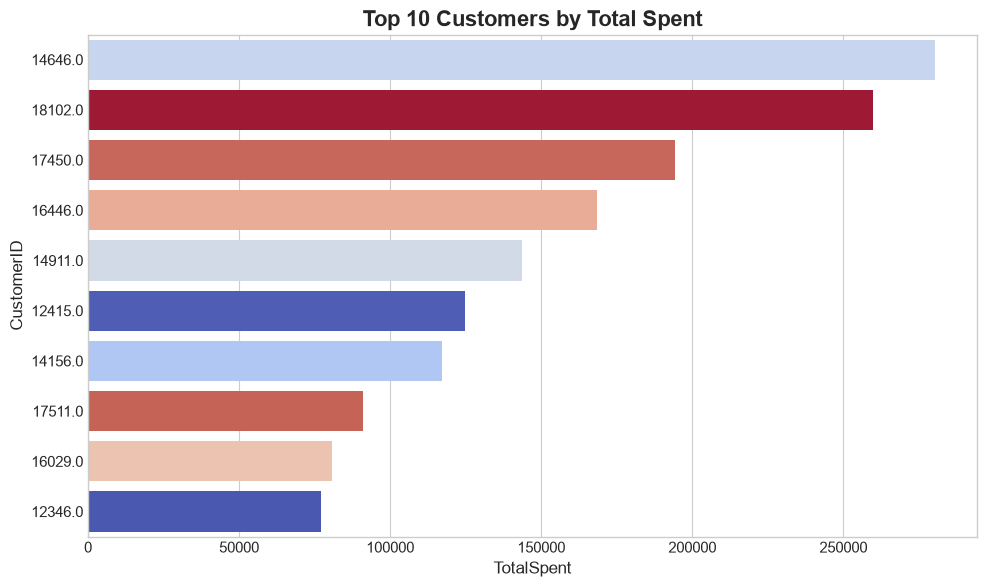

In [143]:
sns.barplot(x=top_customers['TotalSpent'],y=top_customers['CustomerID'].astype(str),hue=top_customers.index,palette='coolwarm',legend=False)
plt.title('Top 10 Customers by Total Spent')

plt.tight_layout()

plt.show()

### 5.2 Time Analysis

##### 5.2.1 Monthly Sales Trend

In [144]:
monthly_sales= df_sales_products.groupby('Month')['TotalSales'].sum().reset_index()
print(monthly_sales)

    Month   TotalSales
0       1   670654.460
1       2   508081.540
2       3   690591.840
3       4   515884.661
4       5   740487.330
5       6   738233.990
6       7   688802.671
7       8   724708.160
8       9  1029275.382
9      10  1104060.920
10     11  1453295.980
11     12  1391044.200


##### Monthly Sales Trend: Full vs. Clean
*Comparison between all months and excluding Month 12.*

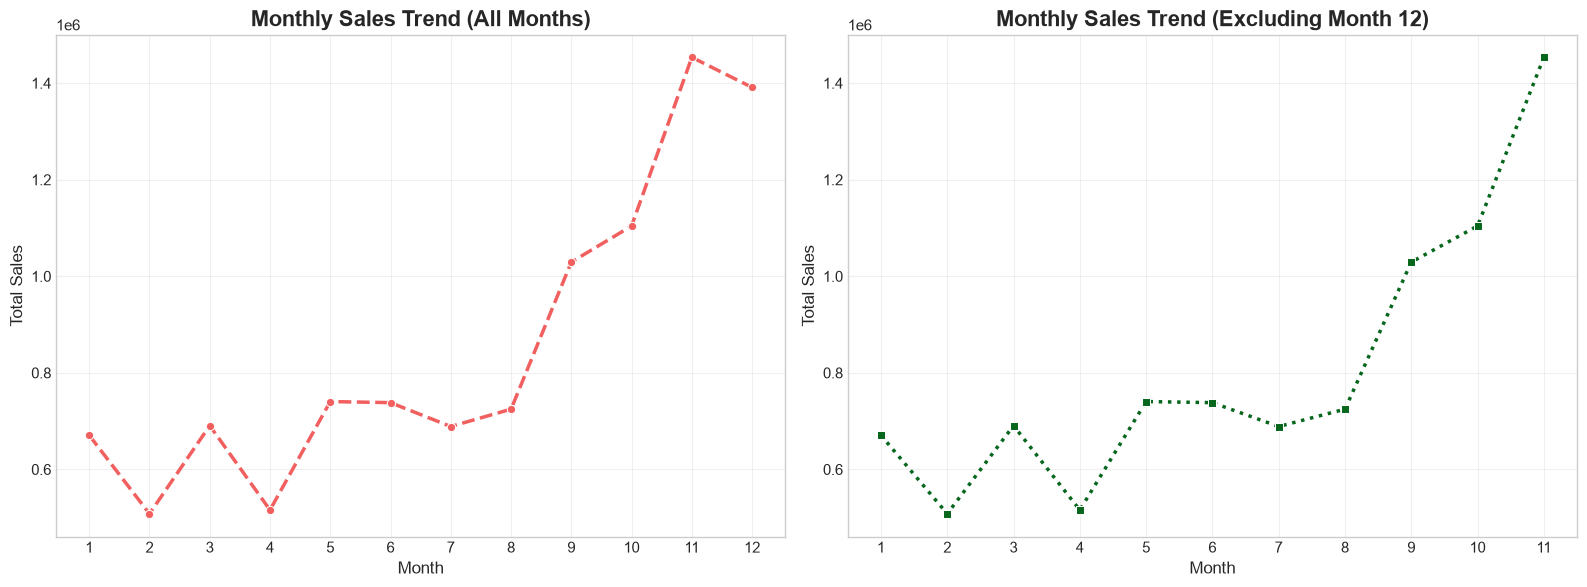

In [145]:
monthly_sales_clean = monthly_sales[monthly_sales['Month'] != 12]

fig ,axes = plt.subplots(1,2,figsize=(16,6))


sns.lineplot(x= 'Month' , y= 'TotalSales' , data=monthly_sales ,
             marker='o',
             color='#F15F5F',
             linestyle='--',
             linewidth=2.5,
             ax=axes[0])
axes[0].set_title('Monthly Sales Trend (All Months)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales')
axes[0].set_xticks(range(1,13))
axes[0].grid(True,alpha=0.3)



sns.lineplot(x= 'Month' , y= 'TotalSales' , data=monthly_sales_clean ,
             marker='s',
             color="#06661B",
             linestyle='dotted',
             linewidth=2.5,
             ax=axes[1])
axes[1].set_title('Monthly Sales Trend (Excluding Month 12)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales')
axes[1].set_xticks(range(1,12))
axes[1].grid(True,alpha=0.3)

plt.tight_layout()

plt.show()


##### 5.2.2 Sales by Day Of Week

In [146]:
day_sales =df_sales_products.groupby('DayOfWeek')['TotalSales'].sum().reset_index()
day_sales

,DayOfWeek,TotalSales
0,0,1684294.561
1,1,2086320.321
2,2,1783645.880
3,3,2133746.600
4,4,1768302.271
5,6,798811.501


In [147]:
day_names= {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
day_sales['DayName']=day_sales['DayOfWeek'].map(day_names)

print(day_sales[['DayName','TotalSales']].sort_values('TotalSales',ascending=False))

     DayName   TotalSales
3   Thursday  2133746.600
1    Tuesday  2086320.321
2  Wednesday  1783645.880
4     Friday  1768302.271
0     Monday  1684294.561
5     Sunday   798811.501


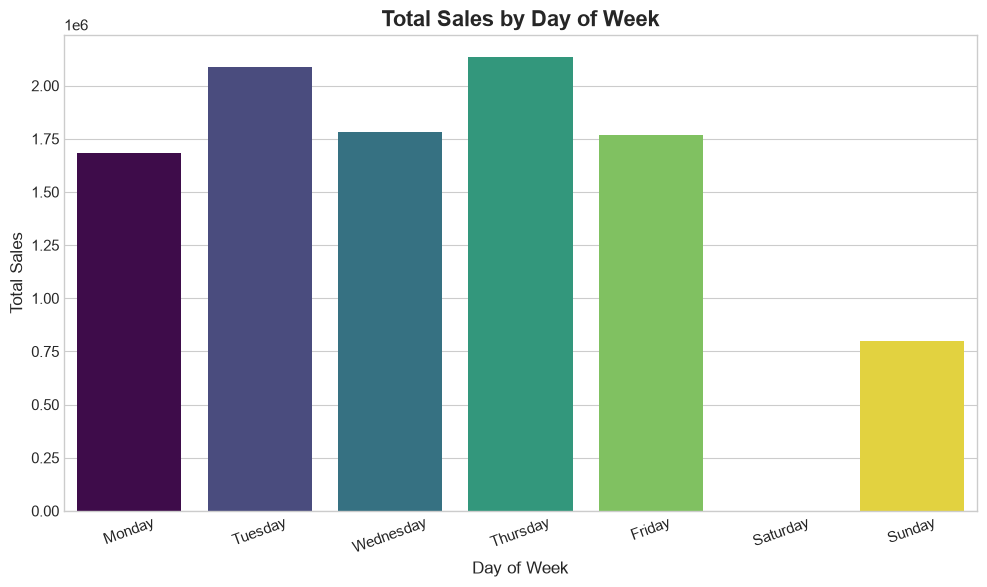

In [148]:
sns.barplot(x='DayName', y='TotalSales', data=day_sales,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            hue=day_sales.index,
            palette='viridis',
            legend=False
            )

plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')

plt.xticks(rotation=20)
plt.tight_layout()


plt.show()

In [149]:
# 1. Check if there are any Saturday transactions in df_sales_products
saturday_data = df_sales_products[df_sales_products['DayOfWeek'] == 5]

print(f"Number of Saturday transactions: {len(saturday_data)}")
print(f"Saturday total sales: {saturday_data['TotalSales'].sum() if len(saturday_data) > 0 else 0}")

# 2. Check in the ORIGINAL df_Ret (before cleaning)
saturday_original = df_Ret[df_Ret['InvoiceDate'].dt.dayofweek == 5]
print(f"\nSaturday transactions in ORIGINAL data: {len(saturday_original)}")

# 3. Check if Saturday was in the original but removed during cleaning
if len(saturday_original) > 0:
    print(f"\n Saturday data exists in original but was removed!")
    print(f"Sample of original Saturday transactions:")
    print(saturday_original[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))

Number of Saturday transactions: 0
Saturday total sales: 0

Saturday transactions in ORIGINAL data: 0


**Note:** Store is closed on Saturdays (£0). Peak sales on Thursday and Tuesday.

##### 5.2.3 Sales by Hour

In [150]:
hour_sales=df_sales_products.groupby('Hour')['TotalSales'].sum().reset_index()

print('Sales by Hour (Top 10) : ')
print(hour_sales.sort_values('TotalSales',ascending=False).head(10))

Sales by Hour (Top 10) : 
    Hour   TotalSales
6     12  1414006.320
4     10  1402866.401
9     15  1274411.650
7     13  1221376.070
5     11  1197627.550
8     14  1120613.341
3      9   956460.161
10    16   709049.810
11    17   441279.881
2      8   279747.680


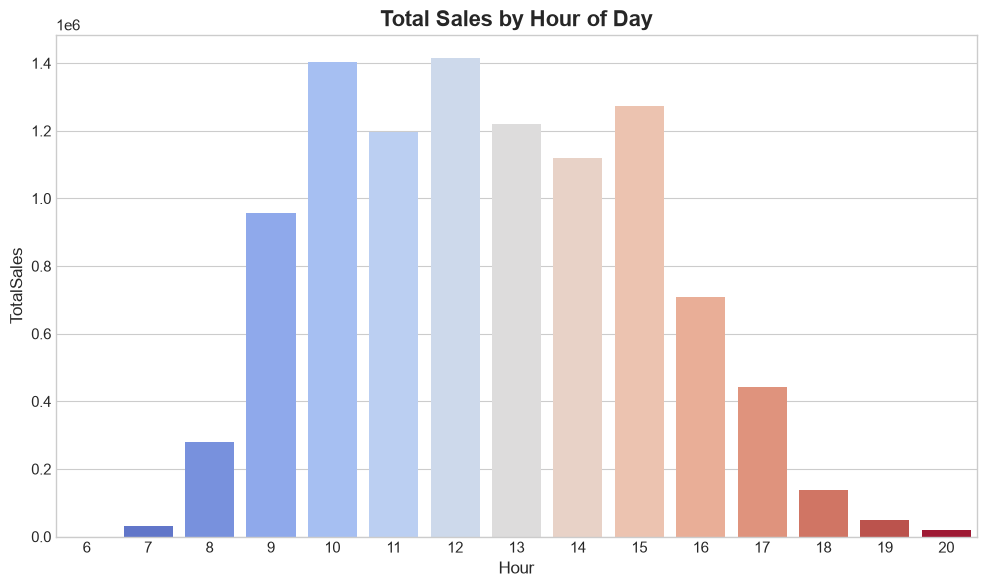

In [151]:
sns.barplot(x='Hour',y='TotalSales',data=hour_sales,hue=hour_sales.index,palette='coolwarm',legend=False)

plt.title('Total Sales by Hour of Day')

plt.tight_layout()

plt.show()

**Note :**
- Peak Hour: 12 PM (£1.41M)
- Second Peak: 10 AM (£1.40M)
- Peak Window: 10 AM – 3 PM
- Dead Hours: 0–6 AM (closed)
- Close Time: ~7 PM


##### 5.2.4 Sales HeatMap (Day vs Hour)

In [152]:
heatmap_data = df_sales_products.pivot_table(index='DayOfWeek',
                                             columns='Hour',
                                             values='TotalSales',
                                             aggfunc='sum'
                                            ).fillna(0)
heatmap_data

Hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
DayOfWeek,,,,,,,,,,,,,,,
0,0.00,1494.58,44375.79,151078.240,213245.420,173281.21,191609.08,229340.57,206530.320,181974.98,112022.03,177124.171,2218.17,0.00,0.00
1,0.00,1962.58,71892.71,185074.740,332925.021,278418.91,260614.01,231319.06,192135.430,290482.57,173493.02,52426.440,15575.83,0.00,0.00
2,0.00,3343.46,44756.27,135630.250,258692.940,217433.63,288256.95,230151.49,195012.710,230705.63,122626.91,41110.740,0.00,2893.40,13031.50
3,4.25,6883.71,66819.20,158986.240,296620.070,181788.69,283943.43,198377.81,208873.680,255815.23,184591.50,118070.610,121309.62,45882.22,5780.34
4,0.00,16834.88,51903.71,324911.891,220555.310,201137.27,236859.27,188510.32,210193.640,187353.86,77026.47,52547.920,75.50,373.04,19.19
6,0.00,0.00,0.00,778.800,80827.640,145567.84,152723.58,143676.82,107867.561,128079.38,39289.88,0.000,0.00,0.00,0.00


In [153]:
day_names= {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}

heatmap_data.index=heatmap_data.index.map(day_names)
heatmap_data

Hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
DayOfWeek,,,,,,,,,,,,,,,
Monday,0.00,1494.58,44375.79,151078.240,213245.420,173281.21,191609.08,229340.57,206530.320,181974.98,112022.03,177124.171,2218.17,0.00,0.00
Tuesday,0.00,1962.58,71892.71,185074.740,332925.021,278418.91,260614.01,231319.06,192135.430,290482.57,173493.02,52426.440,15575.83,0.00,0.00
Wednesday,0.00,3343.46,44756.27,135630.250,258692.940,217433.63,288256.95,230151.49,195012.710,230705.63,122626.91,41110.740,0.00,2893.40,13031.50
Thursday,4.25,6883.71,66819.20,158986.240,296620.070,181788.69,283943.43,198377.81,208873.680,255815.23,184591.50,118070.610,121309.62,45882.22,5780.34
Friday,0.00,16834.88,51903.71,324911.891,220555.310,201137.27,236859.27,188510.32,210193.640,187353.86,77026.47,52547.920,75.50,373.04,19.19
Sunday,0.00,0.00,0.00,778.800,80827.640,145567.84,152723.58,143676.82,107867.561,128079.38,39289.88,0.000,0.00,0.00,0.00


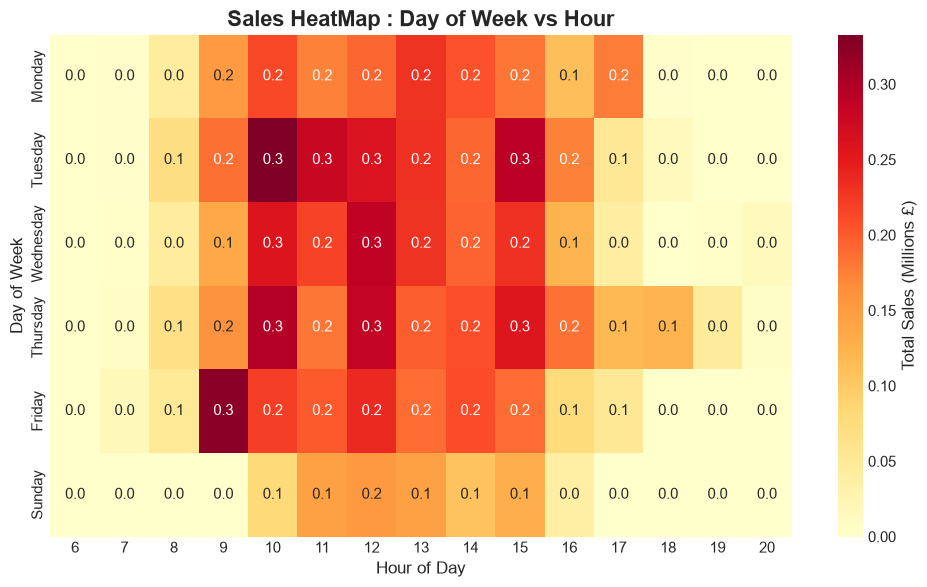

In [154]:
sns.heatmap(heatmap_data/1e6, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Total Sales (Millions £)'})

plt.title('Sales HeatMap : Day of Week vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()

plt.show()

**Note :** 

- Peak Sales: Tuesday-Thursday × 10 AM - 3 PM
- Hotspot Value: £300K per hour
- Saturday: No sales (store closed)
- Sunday: Low activity (0.1-0.2 millions)
- Dead hours: Before 9 AM and after 5 PM

##### 5.2.5 Sales : Weekend vs Weekday

In [155]:
weekend_sales=df_sales_products.groupby('IsWeekend')['TotalSales'].sum().reset_index()
weekend_sales

,IsWeekend,TotalSales
0,0,9456309.633
1,1,798811.501


In [156]:
weekend_sales['Type']=weekend_sales['IsWeekend'].map({0:'weekday',1:'weekend'})
weekend_sales

,IsWeekend,TotalSales,Type
0,0,9456309.633,weekday
1,1,798811.501,weekend


In [157]:
total= weekend_sales['TotalSales'].sum()
weekend_sales['Percentage']=(weekend_sales['TotalSales'] / total * 100).round(2)

print(' Sales : Weekend vs Weekday : \n')
print(weekend_sales[['Type','TotalSales','Percentage']])

 Sales : Weekend vs Weekday : 

      Type   TotalSales  Percentage
0  weekday  9456309.633       92.21
1  weekend   798811.501        7.79


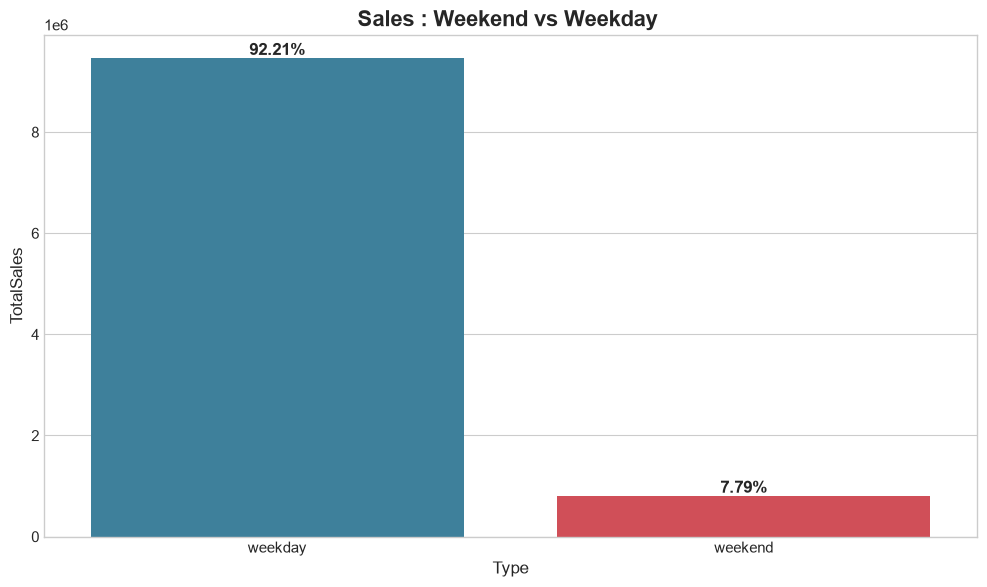

In [158]:
ax=sns.barplot(x='Type',y='TotalSales',data=weekend_sales,hue=weekend_sales.index,palette=['#2E86AB','#E63946'],legend=False)

plt.title('Sales : Weekend vs Weekday ')

# to add percentage labels
for i, p in enumerate(ax.patches):
    percentage = weekend_sales['Percentage'].iloc[i]
    ax.annotate(f'{percentage}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.show()

### 5.3 Product Analysis 

##### 5.3.1 Product Return Analysis

In [159]:
returns = df_Ret[df_Ret['Quantity'] < 0 ].copy()
returns

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [160]:
returns['ReturnQuantity'] = returns['Quantity'].abs()
returns.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnQuantity
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,1
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,1
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,12
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,24
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,24


In [161]:
print(f'Total return transactions: {len(returns):,}')
print(f'Total return items:{returns['ReturnQuantity'].sum():,}')

Total return transactions: 10,624
Total return items:484,531


In [162]:
top_returns= returns.groupby('Description')['ReturnQuantity'].sum().nlargest(10)
print('Top 10 Returned Products : \n',top_returns)

Top 10 Returned Products : 
 Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
printing smudges/thrown away           19200
Unsaleable, destroyed.                 15644
check                                  13247
?                                       9496
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Printing smudges/thrown away            9058
Damaged                                 7540
throw away                              5368
Name: ReturnQuantity, dtype: int64


In [163]:
# Exclude non Product Return Entries
non_product_returns = [
    'printing smudges/thrown away', 'Printing smudges/thrown away',
    'Unsaleable, destroyed.', 'check', '?', 'Damaged', 'damages',
    'throw away', 'thrown away', 'thrown away-can\'t sell', 'Thrown away-rusty',
    'mouldy, thrown away.', 'incorrect stock entry.', 'wrongly marked. 23343 in box',
    'damages wax', 'Manual', 'sold as set on dotcom',
    'DOTCOM POSTAGE', 'POSTAGE', 'BANK CHARGES', 'AMAZON FEE',
    'CRUK Commission', 'Discount', 'Adjust bad debt'
]
returns_clean=returns[~returns['Description'].isin(non_product_returns)]

top_returns_clean= returns_clean.groupby('Description')['ReturnQuantity'].sum().nlargest(10)
print('Top 10 Returned Products (excluding non-products) : \n',top_returns_clean)

Top 10 Returned Products (excluding non-products) : 
 Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
WHITE HANGING HEART T-LIGHT HOLDER      2578
?missing                                2331
GIN + TONIC DIET METAL SIGN             2030
??                                      1849
damaged                                 1824
Name: ReturnQuantity, dtype: int64


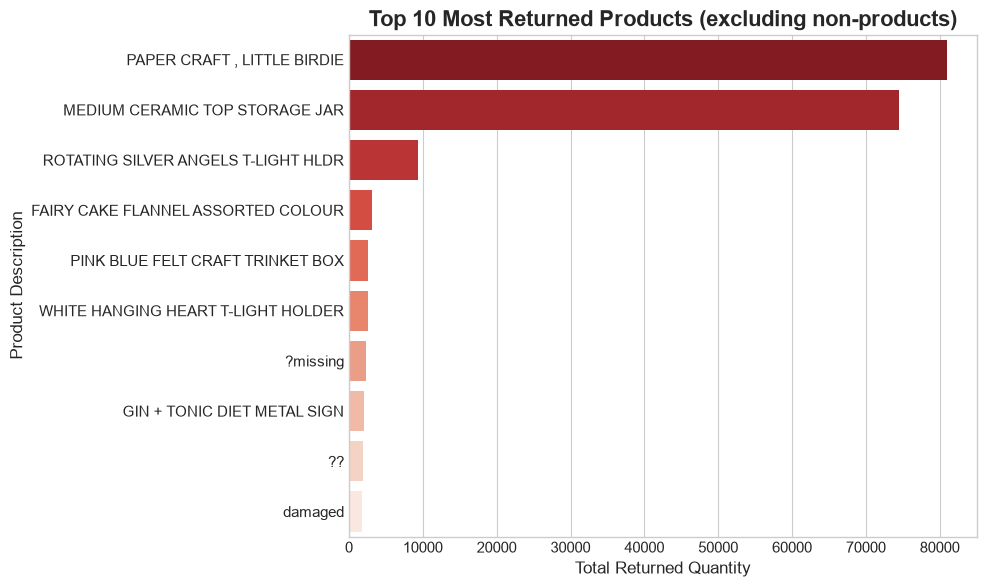

In [164]:
sns.barplot(x=top_returns_clean.values,y=top_returns_clean.index,hue=top_returns_clean.index,palette='Reds_r',legend=False)

plt.title('Top 10 Most Returned Products (excluding non-products)')
plt.xlabel('Total Returned Quantity')
plt.ylabel('Product Description')

plt.tight_layout()

plt.show()

*Key Insight:* 
- PAPER CRAFT, LITTLE BIRDIE: 80,995 returned (~100% of sales)
- MEDIUM CERAMIC TOP STORAGE JAR: 74,494 returned (~95% of sales)

Both are also the top 2 best-sellers by quantity, indicating a critical quality or description issue.

**Note:** Some entries in the list are administrative records (e.g., "damaged", "?missing") rather than actual products.

##### 5.3.2 Return Rate by Product

In [165]:
sales_positive =df_Ret[df_Ret['Quantity'] > 0].groupby('Description')['Quantity'].sum()
sales_positive

Description
 4 PURPLE FLOCK DINNER CANDLES     144
 50'S CHRISTMAS GIFT BAG LARGE    1915
 DOLLY GIRL BEAKER                2455
 I LOVE LONDON MINI BACKPACK       389
 I LOVE LONDON MINI RUCKSACK         1
                                  ... 
wrongly coded 20713                800
wrongly coded 23343               1000
wrongly marked                      48
wrongly marked 23343               200
wrongly sold (22719) barcode       170
Name: Quantity, Length: 4077, dtype: int64

In [166]:
sales_negative=df_Ret[df_Ret['Quantity'] < 0].groupby('Description')['Quantity'].apply(lambda x:x.abs().sum())
sales_negative

Description
20713                                400
 50'S CHRISTMAS GIFT BAG LARGE         2
 DOLLY GIRL BEAKER                     7
 OVAL WALL MIRROR DIAMANTE             5
 SET 2 TEA TOWELS I LOVE LONDON        8
                                    ... 
wrongly coded-23343                  800
wrongly marked carton 22804          256
wrongly marked. 23343 in box        3100
wrongly sold as sets                 600
wrongly sold sets                    975
Name: Quantity, Length: 2110, dtype: int64

In [167]:
return_analysis = pd.concat([sales_positive, sales_negative], axis=1)
return_analysis.columns = ['Sold', 'Returned']
return_analysis = return_analysis.fillna(0)

return_analysis['ReturnRate'] = (return_analysis['Returned'] / return_analysis['Sold'] * 100).round(2)

print(f"\nShape: {return_analysis.shape}")
print("\nFirst 5 rows:")
print(return_analysis.head())


Shape: (4223, 3)

First 5 rows:
                                 Sold  Returned  ReturnRate
Description                                                
4 PURPLE FLOCK DINNER CANDLES   144.0       0.0        0.00
50'S CHRISTMAS GIFT BAG LARGE  1915.0       2.0        0.10
DOLLY GIRL BEAKER              2455.0       7.0        0.29
I LOVE LONDON MINI BACKPACK     389.0       0.0        0.00
I LOVE LONDON MINI RUCKSACK       1.0       0.0        0.00


In [168]:
non_products = ['check', 'damaged', '?', '??', '?missing', 'check?',
                'wrongly coded 20713', 'incorrectly credited C550456 see 47',
                'damages', 'thrown away', 'thrown away-can\'t sell',
                'Thrown away-rusty', 'mouldy, thrown away.',
                'incorrect stock entry.', 'wrongly marked. 23343 in box',
                'damages wax', 'Manual', 'DOTCOM POSTAGE', 'POSTAGE',
                'BANK CHARGES', 'AMAZON FEE', 'CRUK Commission', 
                'Discount', 'Adjust bad debt', 'printing smudges/thrown away',
                'Printing smudges/thrown away', 'Unsaleable, destroyed.']

In [169]:
# filter products with at least 100 sold unit
return_analysis_filtered = return_analysis[(~return_analysis.index.isin(non_products))& (return_analysis['Sold'] >= 100)]

print(f'Products after fitering : {return_analysis_filtered.shape[0]}')

Products after fitering : 2763


In [170]:
# Top 10 Highest Returned Rate : 
top_return_rate = return_analysis_filtered.nlargest(10,'ReturnRate')
top_return_rate

,Sold,Returned,ReturnRate
Description,,,
"PAPER CRAFT , LITTLE BIRDIE",80995.0,80995.0,100.00
ROTATING SILVER ANGELS T-LIGHT HLDR,9476.0,9376.0,98.94
MEDIUM CERAMIC TOP STORAGE JAR,78033.0,74494.0,95.46
SET OF 3 BABUSHKA STACKING TINS,275.0,255.0,92.73
PANTRY CHOPPING BOARD,1154.0,946.0,81.98
IVORY CHANDELIER T-LIGHT HOLDER,658.0,432.0,65.65
BEADED CHANDELIER T-LIGHT HOLDER,698.0,433.0,62.03
FLOWERS CHANDELIER T-LIGHT HOLDER,963.0,579.0,60.12
TEA TIME PARTY BUNTING,2581.0,1424.0,55.17


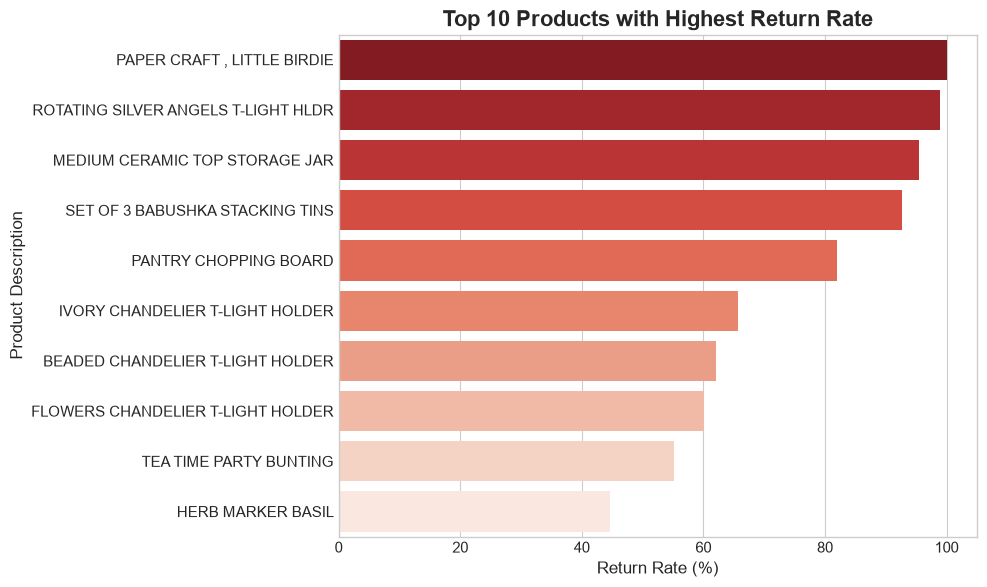

In [171]:
sns.barplot(x=top_return_rate['ReturnRate'],y=top_return_rate.index,hue=top_return_rate.index,palette='Reds_r',legend=False)

plt.title('Top 10 Products with Highest Return Rate')
plt.xlabel('Return Rate (%)')
plt.ylabel('Product Description')

plt.tight_layout()

plt.show()


**Note:** Top returned products match the top best-sellers (~100% return rate). Multiple T-Light Holders appear, **indicating a category-level issue**.

### 5.4 Customer Analysis

##### 5.4.1 (Recency Frequency Monetary )RFM Analysis

*RFM Analysis:*
- *Recency (R):* Days since last purchase → Fewer = Better
- *Frequency (F):* Number of orders → More = Better
- *Monetary (M):* Total spending → Higher = Better

In [172]:
reference_date= df_sales_products['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

##### 5.4.2 Calculate RFM

In [173]:
rfm = df_sales_products.groupby('CustomerID').agg({
                                                'InvoiceDate':lambda x:
                                                 (reference_date - x.max()).days,
                                                 'InvoiceNo':'nunique',
                                                 'TotalSales':'sum'
                                                 
                                                 }).reset_index()
rfm

,CustomerID,InvoiceDate,InvoiceNo,TotalSales
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1437.24
3,12349.0,19,1,1457.55
4,12350.0,310,1,294.40
...,...,...,...,...
4330,18280.0,278,1,180.60
4331,18281.0,181,1,80.82
4332,18282.0,8,2,178.05
4333,18283.0,4,16,2039.58


In [174]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Summary:")
print(rfm.describe())
print(f"\nTotal customers: {len(rfm):,}")

RFM Summary:
         CustomerID      Recency    Frequency       Monetary
count   4335.000000  4335.000000  4335.000000    4335.000000
mean   15299.372549    92.708651     4.248212    2017.088499
std     1721.813812   100.206617     7.646024    8919.392095
min    12346.000000     1.000000     1.000000       3.750000
25%    13812.500000    18.000000     1.000000     304.250000
50%    15298.000000    51.000000     2.000000     663.610000
75%    16778.500000   143.000000     5.000000    1631.475000
max    18287.000000   374.000000   206.000000  279138.020000

Total customers: 4,335


##### 5.4.3 RFM Scoring

In [175]:
rfm['R_Score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_Score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

print('RFM Scores created')
print(rfm[['CustomerID','Recency','R_Score','Frequency','F_Score','Monetary','M_Score']].head())

RFM Scores created
   CustomerID  Recency R_Score  Frequency F_Score  Monetary M_Score
0     12346.0      326       1          1       1  77183.60       5
1     12347.0        2       5          7       5   4310.00       5
2     12348.0       75       2          4       4   1437.24       4
3     12349.0       19       4          1       1   1457.55       4
4     12350.0      310       1          1       1    294.40       2


In [176]:
rfm['RFM_Score']= rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print('RFM Score Distribution :')
print(rfm['RFM_Score'].value_counts().head(10))

RFM Score Distribution :
RFM_Score
555    348
111    180
455    179
121    155
112    126
444    121
122     96
233     88
544     87
344     84
Name: count, dtype: int64


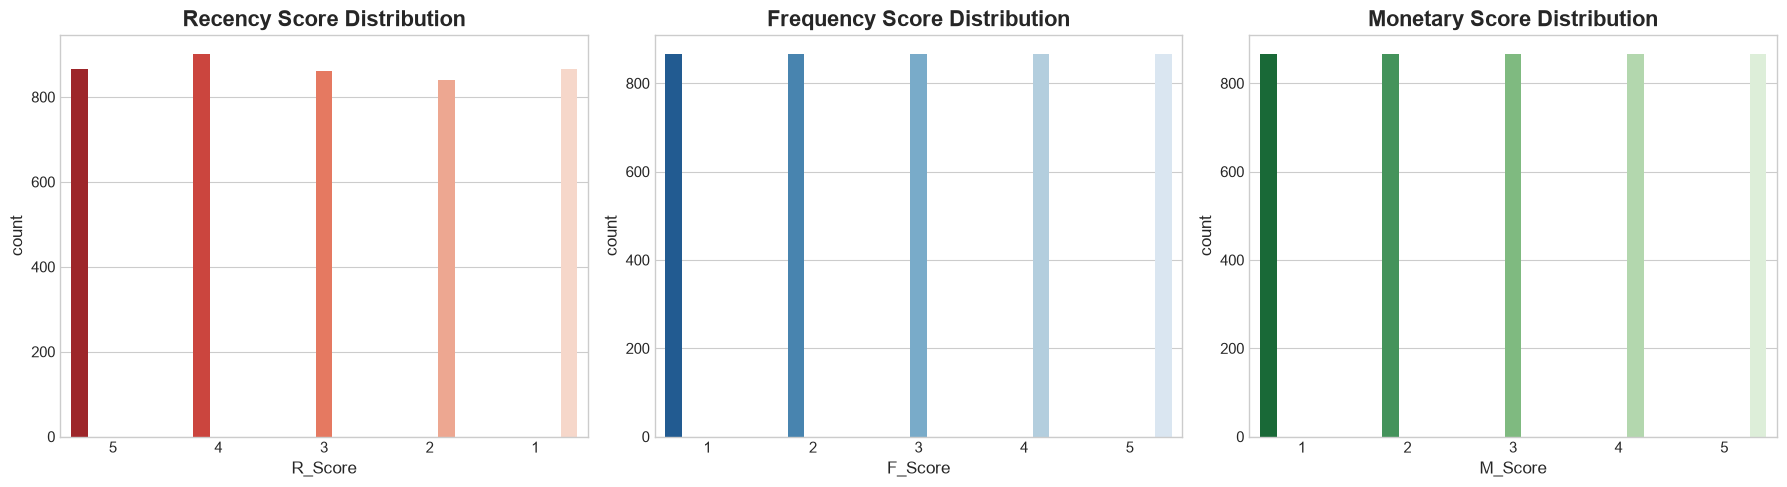

In [177]:
fig,axes=plt.subplots(1,3,figsize=(18,5))

sns.countplot(x='R_Score',data=rfm,hue='R_Score',palette='Reds_r',ax=axes[0],legend=False)
axes[0].set_title('Recency Score Distribution')

sns.countplot(x='F_Score',data=rfm,hue='F_Score',palette='Blues_r',ax=axes[1],legend=False)
axes[1].set_title('Frequency Score Distribution')

sns.countplot(x='M_Score',data=rfm,hue='M_Score',palette='Greens_r',ax=axes[2],legend=False)
axes[2].set_title('Monetary Score Distribution')

plt.tight_layout()

plt.show()

**Note:** The scores are evenly distributed (qcut), with ~867 customers per score. Recency scores are reversed (5 = most recent, 1 = oldest).

##### 5.4.4 Customer Segmentation

In [178]:
def rfm_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4 :
        return 'Champions'
    
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3 :
        return 'Loyal Customers'
    
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2 :
        return 'New Customers'
    
    elif row['R_Score'] <=2 and row['F_Score'] >= 3 :
        return 'Lost Customers'
    
    else:
        return 'Potential Loyalists'
    

rfm['Segment']= rfm.apply(rfm_segment,axis=1)

print('Customer Segments Distribution : ')
print(rfm['Segment'].value_counts())




Customer Segments Distribution : 
Segment
Potential Loyalists    1654
Champions               955
Loyal Customers         769
Lost Customers          638
New Customers           319
Name: count, dtype: int64


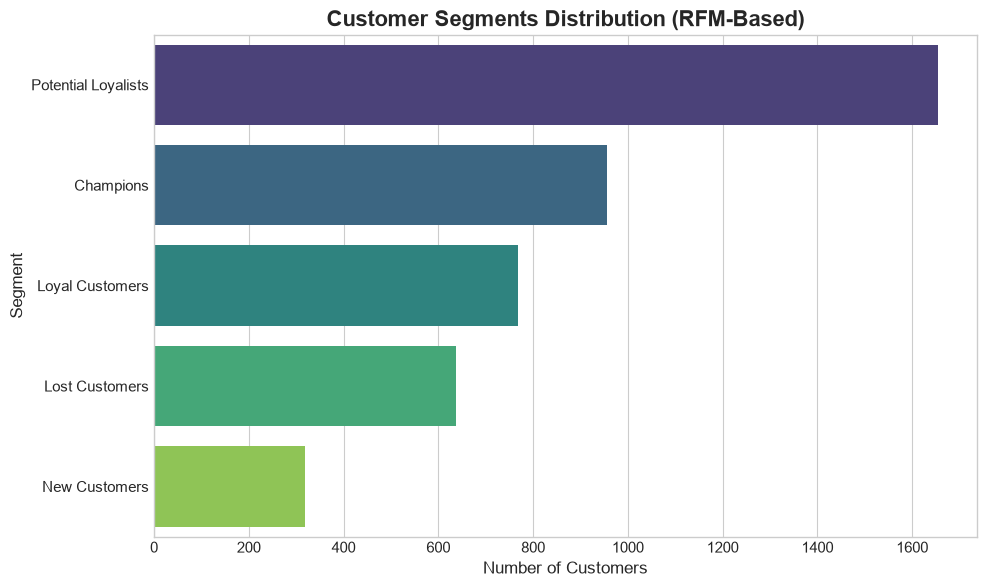

In [179]:
segment_counts =rfm['Segment'].value_counts()

sns.barplot(x=segment_counts.values,y=segment_counts.index,hue=segment_counts.index,palette='viridis',legend=False)

plt.title('Customer Segments Distribution (RFM-Based)')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.tight_layout()

plt.show()

**Key Insights:**
- Potential Loyalists (~1,650) = largest segment → growth opportunity.
- Champions (~950) = most valuable → focus on retention.
- Lost Customers (~650) = churn risk → need win-back campaigns.
- New Customers (~300) = low → acquisition needs improvement.

**Recommendation:** Convert Potential Loyalists to Loyal Customers; retain Champions with VIP treatment.

##### 5.4.5 Churn Risk Analysis

In [180]:
# Identify churn risk customers

churn_threshold = 180  # 6 months without purchase

churn_risk = rfm[rfm['Recency'] > churn_threshold]

print('Churn Risk Analysis :')
print(f'Threshold: {churn_threshold} days without purchase')
print(f'Customers at risk: {len(churn_risk):,}')
print(f'Percentage: {len(churn_risk) / len(rfm) * 100:.2f}%')
print(f'\nTotal revenue at risk: {churn_risk['Monetary'].sum():,.2f}')

Churn Risk Analysis :
Threshold: 180 days without purchase
Customers at risk: 862
Percentage: 19.88%

Total revenue at risk: 553,626.03


Churn Risk by Segment:
Segment
Potential Loyalists    667
Lost Customers         195
Name: count, dtype: int64


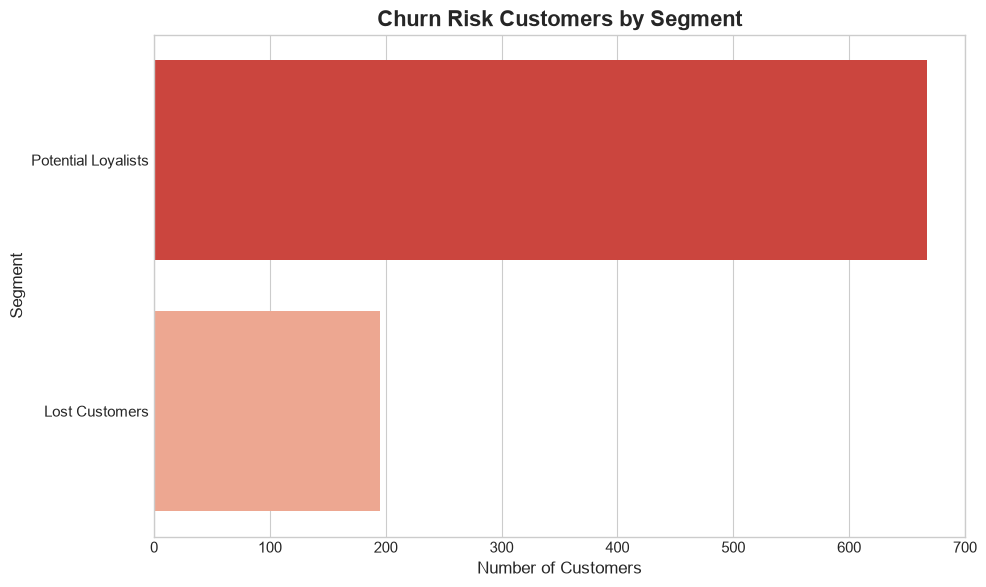

In [181]:
churn_by_segment = churn_risk['Segment'].value_counts()

print('Churn Risk by Segment:')
print(churn_by_segment)


sns.barplot(x=churn_by_segment.values, y=churn_by_segment.index,hue=churn_by_segment.index, palette='Reds_r', legend=False)

plt.title('Churn Risk Customers by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.tight_layout()

plt.show()

**Note:** The 862 churn-risk customers are split into:
- **Potential Loyalists:** 667 (77%) → recoverable with targeted campaigns
- **Lost Customers:** 195 (23%) → require win-back strategies

**Insight:** Most at-risk customers still have purchase history, indicating they can be re-engaged.

### 5.5 Geographic Analysis

##### 5.5.1 Sales by Country

In [182]:
country_sales = df_sales_products.groupby('Country')['TotalSales'].sum().nlargest(10)
print('Top 10 Countries by Revenue : ', country_sales.head(10))

Top 10 Countries by Revenue :  Country
United Kingdom    8726769.484
Netherlands        283889.340
EIRE               276090.860
Germany            205381.150
France             184679.000
Australia          138103.810
Spain               55706.560
Switzerland         53065.600
Japan               37416.370
Belgium             36927.340
Name: TotalSales, dtype: float64


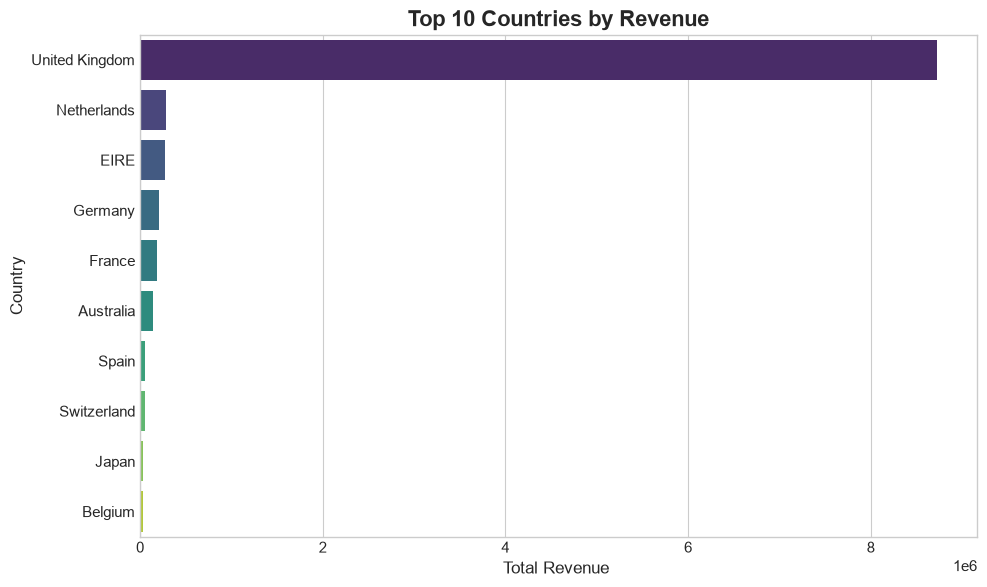

In [183]:
sns.barplot(x=country_sales.values, y=country_sales.index, hue=country_sales.index, palette='viridis', legend=False)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue ')
plt.ylabel('Country')

plt.tight_layout()

plt.show()

**Key Insight:**
- **United Kingdom dominates** with ~87% of top-10 revenue (£8.73M).
- Netherlands, EIRE, Germany, and France together contribute only ~9.5%.
- The gap between UK and the second-largest market (Netherlands) is **31x**.

**Business Implication:**
Heavy reliance on a single market (UK) poses a strategic risk. 
Diversifying into European markets (Netherlands, Germany, France) 
should be a priority for sustainable growth.

##### 5.5.2 Customers by Country

In [184]:
country_customers = df_sales_products.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False ).head(10)
country_customers

Country
United Kingdom    3917
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

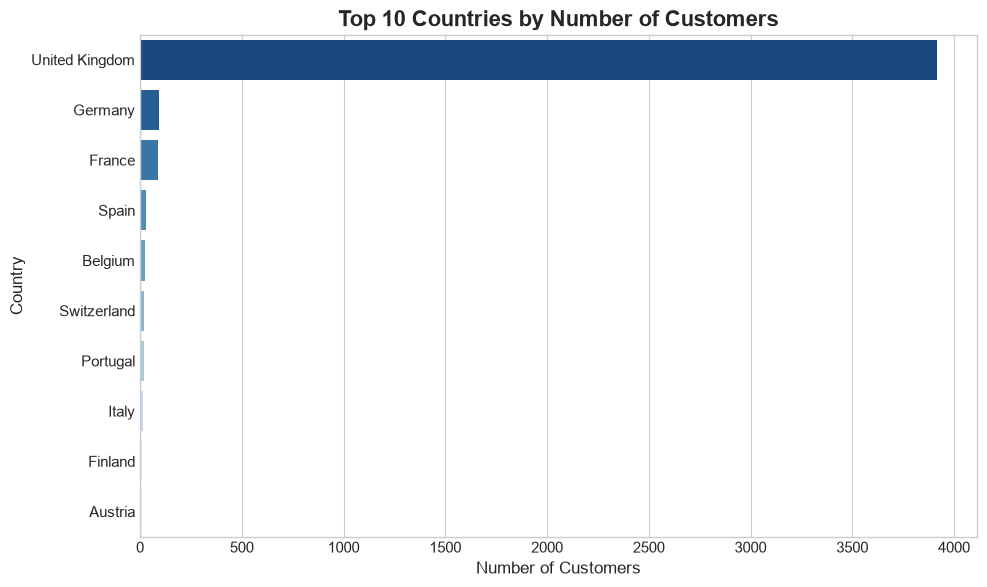

In [185]:
sns.barplot(x=country_customers.values,y=country_customers.index,hue=country_customers.index,palette='Blues_r',legend=False)

plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Country')

plt.tight_layout()

plt.show()

**Note:** UK has ~3,900 customers (~90%). All other countries have <100 each. Business is heavily UK-focused.

##### 5.5.3 Average Order Value by Country

In [186]:
country_avg =df_sales_products.groupby('Country')['TotalSales'].mean().sort_values(ascending=False).head(10)
country_avg

Country
Netherlands    122.260698
Australia      117.037127
Japan          116.561900
Sweden          86.250187
Denmark         49.622180
Lithuania       47.458857
Singapore       42.420419
Bahrain         41.896667
Lebanon         37.641778
Brazil          35.737500
Name: TotalSales, dtype: float64

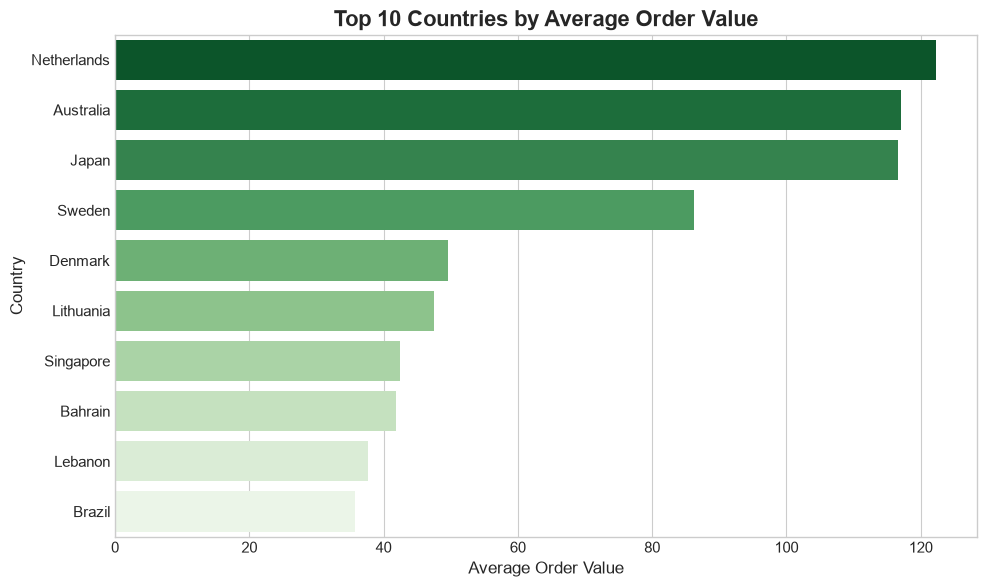

In [187]:
sns.barplot(x=country_avg.values,y=country_avg.index,hue=country_avg.index,palette='Greens_r',legend=False)

plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Country')

plt.tight_layout()

plt.show()

**Note:** Netherlands leads with ~£120 average order value, followed by Australia (~£115) and Japan (~£110). Notably, the UK is absent from this list — despite being the largest market, its average order value is lower. High-value markets present expansion opportunities.

### 5.6 Cross-Analysis

##### 5.6.1 Country x Product

In [188]:
top_countries = ['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France']

summary = []

for country in top_countries:
    country_data = df_sales_products[df_sales_products['Country'] == country]
    top_products = country_data.groupby('Description')['Quantity'].sum().nlargest(5)
    
    for rank, (product, qty) in enumerate(top_products.items(), 1):
        summary.append({
            'Country': country,
            'Rank': rank,
            'Product': product,
            'Quantity': qty
        })

df_summary = pd.DataFrame(summary)


print("Top 5 Products per Country:")
display(df_summary.pivot_table(
    index='Country', 
    columns='Rank', 
    values='Product', 
    aggfunc='first'
))

Top 5 Products per Country:


Rank,1,2,3,4,5
Country,,,,,
EIRE,PACK OF 72 RETROSPOT CAKE CASES,60 TEATIME FAIRY CAKE CASES,VINTAGE SNAP CARDS,60 CAKE CASES VINTAGE CHRISTMAS,ASSORTED INCENSE PACK
France,RABBIT NIGHT LIGHT,MINI PAINT SET VINTAGE,RED TOADSTOOL LED NIGHT LIGHT,SET/6 RED SPOTTY PAPER CUPS,ASSORTED COLOUR BIRD ORNAMENT
Germany,ROUND SNACK BOXES SET OF4 WOODLAND,ASSORTED COLOURS SILK FAN,WOODLAND CHARLOTTE BAG,PACK OF 72 RETROSPOT CAKE CASES,PACK OF 6 BIRDY GIFT TAGS
Netherlands,RABBIT NIGHT LIGHT,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,PACK OF 72 RETROSPOT CAKE CASES,ROUND SNACK BOXES SET OF4 WOODLAND
United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",MEDIUM CERAMIC TOP STORAGE JAR,WORLD WAR 2 GLIDERS ASSTD DESIGNS,JUMBO BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER


##### 5.6.2 Time x Customer

In [189]:
# Meging RFM with the original data

df_with_segment= df_sales_products.merge(rfm[['CustomerID','Segment']],on='CustomerID',how='left')

print(f'Shape: {df_with_segment.shape}')
print(f'\nSegment in data:')
print(df_with_segment['Segment'].value_counts())

Shape: (522724, 15)

Segment in data:
Segment
Champions              231684
Loyal Customers         70848
Potential Loyalists     41333
Lost Customers          37417
New Customers           10016
Name: count, dtype: int64


Average Purchase Hour by Segment :
Segment
New Customers          13.006589
Lost Customers         12.803432
Potential Loyalists    12.744175
Champions              12.705124
Loyal Customers        12.685284
Name: Hour, dtype: float64


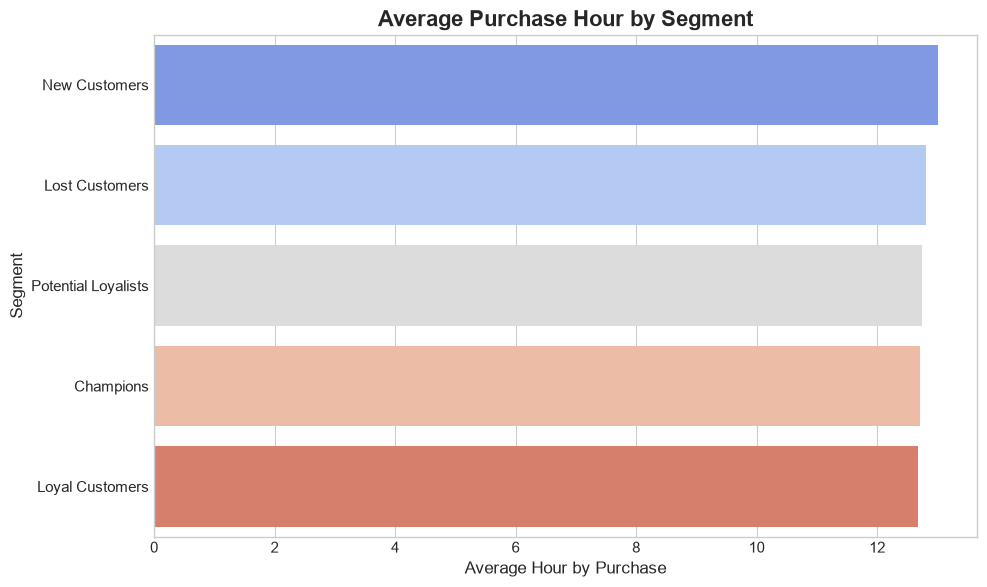

In [190]:
#Purchase Time Analysis by Segment

segment_hour= df_with_segment.groupby('Segment')['Hour'].mean().sort_values(ascending=False)
print('Average Purchase Hour by Segment :')
print(segment_hour)

sns.barplot(x=segment_hour.values,y=segment_hour.index,hue=segment_hour.index,palette='coolwarm',legend=False)

plt.title('Average Purchase Hour by Segment')
plt.xlabel('Average Hour by Purchase')
plt.ylabel('Segment')

plt.tight_layout()

plt.show()


Purchase Distribution by Segment and Day : 
DayOfWeek                0      1      2      3      4      6
Segment                                                      
Champions            38040  39564  40924  47404  32234  33518
Lost Customers        5651   5687   7096   7995   4594   6394
Loyal Customers      11355  12284  11446  13735   9581  12447
New Customers         2278   1706   1166   1634   1410   1822
Potential Loyalists   6668   6274   7160   8176   6141   6914


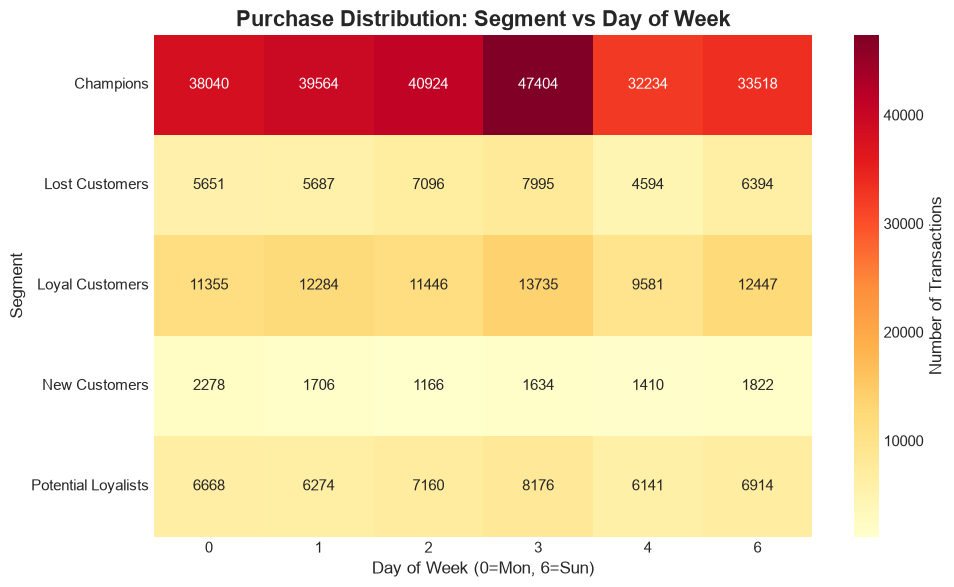

In [191]:
# Purchase Day Analysis by Segment

segment_day= df_with_segment.groupby(['Segment','DayOfWeek']).size().unstack()

print('Purchase Distribution by Segment and Day : ')
print(segment_day)

sns.heatmap(segment_day, cmap='YlOrRd', annot=True, fmt='.0f',
            cbar_kws={'label': 'Number of Transactions'})

plt.title('Purchase Distribution: Segment vs Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Segment')

plt.tight_layout()
plt.show()

**Key Insight:** All segments peak on **Thursday** and drop on **Friday**. New Customers prefer **Monday**. Average purchase hour is consistent (~12–13 PM) across all segments.

**Action:** Schedule campaigns on **Thursdays**; target new customers on **Mondays**.

##### 5.6.3 Customer x Returns

In [192]:
# Linking Customers to Returns

returns_per_customer= df_Ret[df_Ret['Quantity'] < 0].groupby('CustomerID')['Quantity'].apply(lambda x:x.abs().sum())

df_returns= rfm.copy()
df_returns['Returns']= df_returns['CustomerID'].map(returns_per_customer).fillna(0)

df_returns['ReturnRate']= (df_returns['Returns'] / df_returns['Monetary'] * 100).round(2)

print('Returns Analysis : ')
print(df_returns[['CustomerID', 'Monetary', 'Returns', 'ReturnRate', 'Segment']].head(10))

Returns Analysis : 
   CustomerID  Monetary  Returns  ReturnRate              Segment
0     12346.0  77183.60  74215.0       96.15  Potential Loyalists
1     12347.0   4310.00      0.0        0.00            Champions
2     12348.0   1437.24      0.0        0.00       Lost Customers
3     12349.0   1457.55      0.0        0.00        New Customers
4     12350.0    294.40      0.0        0.00  Potential Loyalists
5     12352.0   1385.74     66.0        4.76      Loyal Customers
6     12353.0     89.00      0.0        0.00  Potential Loyalists
7     12354.0   1079.40      0.0        0.00  Potential Loyalists
8     12355.0    459.40      0.0        0.00  Potential Loyalists
9     12356.0   2487.43      0.0        0.00      Loyal Customers


Average Returns by Segment:
                     Monetary  Returns
Segment                               
Champions             5979.31    78.00
Lost Customers        1229.43    24.83
Loyal Customers       1770.47   126.48
New Customers          446.95     2.66
Potential Loyalists    450.66    51.57


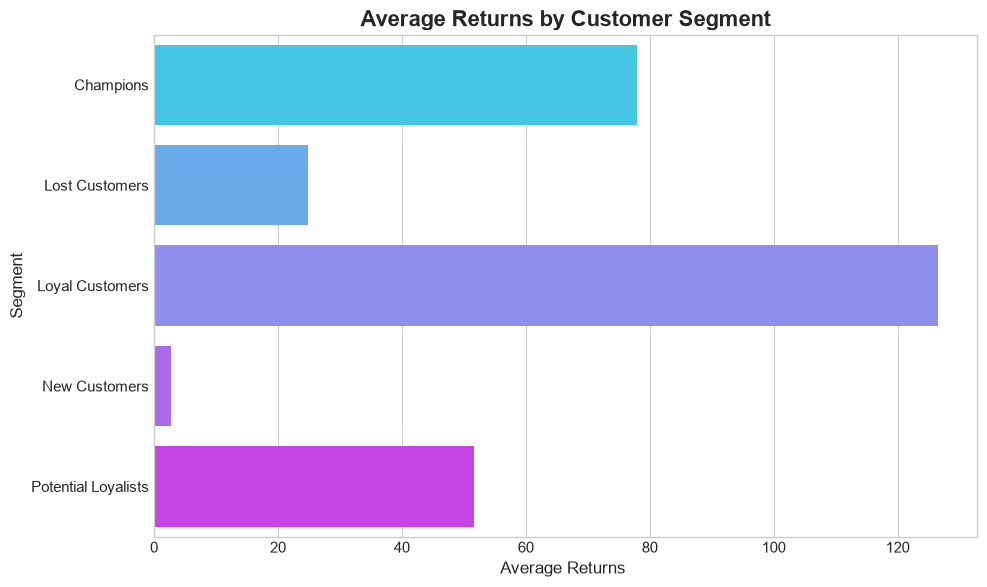

In [193]:
# Average Returns by Segment

segment_returns = df_returns.groupby('Segment')[['Monetary', 'Returns']].mean().round(2)

print("Average Returns by Segment:")
print(segment_returns)


sns.barplot(x=segment_returns['Returns'].values,y=segment_returns.index,hue=segment_returns.index,palette='cool', legend=False)

plt.title('Average Returns by Customer Segment')
plt.xlabel('Average Returns ')
plt.ylabel('Segment')

plt.tight_layout()

plt.show()

**Key Insight:**
- **Loyal Customers** have the highest average returns (£126), despite lower spending than Champions.
- **Champions** return less (£78) relative to their high spending (~£6K).
- **New Customers** have minimal returns (£2.66).

**Business Implication:**
Loyal Customers may be over-ordering or experiencing quality issues. 
Review their return patterns to reduce costs. Champions are highly satisfied — retain them.

---

**Author:** Aryam Khaled  
**Project:** E-Commerce Sales & Customer Intelligence  
**Date:** September 2026  
**Repository:** https://github.com/aryamkhaled/ecommerce-sales-analysis



"Data is not just numbers — it tells a story."

*Thank you for reading!*
